Grupo formado por:
* Silvia Pla Martínez
* Alejandro Moreno Sapena
* Paola Reguera González
* Fátima Cucart Matoses

En esta práctica se aborda un problema de clasificación de sentimientos a partir de un conjunto de datos de tweets relacionados con marcas, medios y servicios de telecomunicaciones. Para ello, se realiza un proceso de exploración y preprocesamiento del texto que incluye tareas de limpieza y normalización, seguido del entrenamiento y evaluación de un modelo basado en redes neuronales convolucionales (CNN) para la identificación automática del sentimiento.

Primero que todo se importan las librerías, la base de datos y se realiza una inspección general de los mismos.

In [83]:
!pip install tensorflow
!pip install langdetect
!pip install unidecode

In [84]:
import pandas as pd
import numpy as np
import re
import string
from google.colab import drive
from unidecode import unidecode
from langdetect import detect, LangDetectException
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense,
    Conv1D, GlobalMaxPooling1D, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import os, random, numpy as np, tensorflow as tf

In [85]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [86]:
df=pd.read_csv('/content/drive/MyDrive/EDEM IA/IA_predictiva/Redes neuronales Adrián/Proyecto/full-corpus.csv')

In [87]:
print(df.columns)

Index(['Topic', 'Sentiment', 'TweetId', 'TweetDate', 'TweetText'], dtype='object')


In [88]:
print(df.head(5))

   Topic Sentiment             TweetId                       TweetDate  \
0  apple  positive  126415614616154112  Tue Oct 18 21:53:25 +0000 2011   
1  apple  positive  126404574230740992  Tue Oct 18 21:09:33 +0000 2011   
2  apple  positive  126402758403305474  Tue Oct 18 21:02:20 +0000 2011   
3  apple  positive  126397179614068736  Tue Oct 18 20:40:10 +0000 2011   
4  apple  positive  126395626979196928  Tue Oct 18 20:34:00 +0000 2011   

                                                                                                                   TweetText  
0                                   Now all @Apple has to do is get swype on the iphone and it will be crack. Iphone that is  
1                                               @Apple will be adding more carrier support to the iPhone 4S (just announced)  
2  Hilarious @youtube video - guy does a duet with @apple 's Siri. Pretty much sums up the love affair! http://t.co/8ExbnQjY  
3                                              

In [89]:
# Dimensiones (filas, columnas)
df.shape

(5113, 5)

In [90]:
# Información general: tipos de datos y nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5113 entries, 0 to 5112
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Topic      5113 non-null   object
 1   Sentiment  5113 non-null   object
 2   TweetId    5113 non-null   int64 
 3   TweetDate  5113 non-null   object
 4   TweetText  5113 non-null   object
dtypes: int64(1), object(4)
memory usage: 199.9+ KB


In [91]:
# Tipos de datos por columna
df.dtypes

,0
Topic,object
Sentiment,object
TweetId,int64
TweetDate,object
TweetText,object


In [92]:
# Número de nulos por columna
df.isnull().sum()

,0
Topic,0
Sentiment,0
TweetId,0
TweetDate,0
TweetText,0


In [93]:
# Porcentaje de nulos
df.isnull().mean() * 100


,0
Topic,0.0
Sentiment,0.0
TweetId,0.0
TweetDate,0.0
TweetText,0.0


A continuación, se lleva a cabo la limpieza y preparación de los datos, que incluye la normalización del texto mediante el uso de minúsculas, la eliminación de signos de puntuación, así como de caracteres especiales y acentos.

In [94]:
# signos de puntuación estándar + españoles
chars = string.punctuation + "“”‘’¿¡"

# patrón regex para eliminar puntuación
re_punc = re.compile('[%s]' % re.escape(chars))

# limpieza de la columna de texto (una review por fila)
df['comment_text_clean'] = (
    df['TweetText']
    .fillna('')
    .str.replace(re_punc, '', regex=True)
)

# comprobar resultado
df[['TweetText', 'comment_text_clean']].head()


,TweetText,comment_text_clean
0,Now all @Apple has to do is get swype on the iphone and it will be crack. Iphone that is,Now all Apple has to do is get swype on the iphone and it will be crack Iphone that is
1,@Apple will be adding more carrier support to the iPhone 4S (just announced),Apple will be adding more carrier support to the iPhone 4S just announced
2,Hilarious @youtube video - guy does a duet with @apple 's Siri. Pretty much sums up the love affair! http://t.co/8ExbnQjY,Hilarious youtube video guy does a duet with apple s Siri Pretty much sums up the love affair httptco8ExbnQjY
3,@RIM you made it too easy for me to switch to @Apple iPhone. See ya!,RIM you made it too easy for me to switch to Apple iPhone See ya
4,I just realized that the reason I got into twitter was ios5 thanks @apple,I just realized that the reason I got into twitter was ios5 thanks apple


In [95]:
!pip install unidecode

In [96]:
df['comment_text_clean'] = (
    df['comment_text_clean']
    .fillna('')
    .apply(unidecode)
)


In [97]:
df['comment_text_clean'] = df['comment_text_clean'].str.lower()


In [98]:
df['comment_text_clean']

,comment_text_clean
0,now all apple has to do is get swype on the iphone and it will be crack iphone that is
1,apple will be adding more carrier support to the iphone 4s just announced
2,hilarious youtube video guy does a duet with apple s siri pretty much sums up the love affair httptco8exbnqjy
3,rim you made it too easy for me to switch to apple iphone see ya
4,i just realized that the reason i got into twitter was ios5 thanks apple
...,...
5108,me re cope con twitter
5109,buenas noches genteeee twitter los quierooo
5110,twitter tiene la mala costumbre de ponerce bno cuano yo me voy
5111,oi flaviasansi muito bem vinda ao meu twitter sempre dou followback pelo meu perfil profissional permaneca por aqui certo abrass


In [99]:
df['tokens'] = df['comment_text_clean'].str.findall(r'\S+')

A simple vista, se puede ver que hay muchos comentarios que incluyen URL. Como no aportan nada de valor, las eliminamos.

In [100]:
df['comment_text_clean'] = df['comment_text_clean'].str.replace(
    r'http\S+|www\S+', '', regex=True
)


En esta parte de código se identifica automáticamente el idioma de cada comentario de nuestro dataset, ignorando aquellos que no contienen texto útil. Luego comprobamos cuántos idiomas se han detectado y si la asignación de idiomas es correcta.

In [101]:
from langdetect import DetectorFactory
DetectorFactory.seed = 42
def safe_detect(text):
    text = str(text).strip()
    if not re.search(r'[A-Za-zÀ-ÿ]', text):
        return 'unknown'
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

df['lang'] = df['comment_text_clean'].apply(safe_detect)
df['lang'].value_counts().head(10)


,count
lang,
en,3647
es,460
fr,167
it,157
pt,132
nl,122
de,65
af,62
so,34


In [102]:
df['lang'].value_counts()

,count
lang,
en,3647
es,460
fr,167
it,157
pt,132
nl,122
de,65
af,62
so,34


In [103]:
df_es = df[df['lang'] == 'es']
print(df_es.head(5))

      Topic   Sentiment             TweetId                       TweetDate  \
815   apple     neutral  125804983185719297  Mon Oct 17 05:26:59 +0000 2011   
954   apple     neutral  125336929825849344  Sat Oct 15 22:27:07 +0000 2011   
1003  apple  irrelevant  126405660308021248  Tue Oct 18 21:13:52 +0000 2011   
1009  apple  irrelevant  126387209824776192  Tue Oct 18 20:00:33 +0000 2011   
1017  apple  irrelevant  126355839274594304  Tue Oct 18 17:55:54 +0000 2011   

                                                                                                                                         TweetText  \
815                                    Fregon el nuevo facebook para iPod/iPhone haha alomejor ya tiene rato pero yo lo acabo de actualizar @apple   
954                                   De la nada mi #iPhone4 se fue a negro y empezó a vibrar, hubo que resetearlo, que onda con #iOS5 WTFH @Apple   
1003  Casi 30 años usando PC, de ellos casi 4 Mac y tengo q decir que el Ma

In [104]:
df_fr = df[df['lang'] == 'fr']
print(df_fr.head(5))

     Topic Sentiment             TweetId                       TweetDate  \
240  apple  negative  126189036644728832  Tue Oct 18 06:53:05 +0000 2011   
264  apple  negative  126106964420857857  Tue Oct 18 01:26:57 +0000 2011   
370  apple  negative  125691072398639104  Sun Oct 16 21:54:21 +0000 2011   
464  apple  negative  125265721281351680  Sat Oct 15 17:44:09 +0000 2011   
479  apple  negative  125129328446017536  Sat Oct 15 08:42:11 +0000 2011   

                                                                         TweetText  \
240                                                                  fuck u @apple   
264                                                          @apple u guys are gay   
370  @Apple, #iOS5 on iPhone2 causes Camera apperature dilation problems & freeze.   
464                                                                      @apple cu   
479                                                            DAMN YOU !!! @apple   

                          

In [105]:
df_nl = df[df['lang'] == 'nl']
print(df_fr.head(5))

     Topic Sentiment             TweetId                       TweetDate  \
240  apple  negative  126189036644728832  Tue Oct 18 06:53:05 +0000 2011   
264  apple  negative  126106964420857857  Tue Oct 18 01:26:57 +0000 2011   
370  apple  negative  125691072398639104  Sun Oct 16 21:54:21 +0000 2011   
464  apple  negative  125265721281351680  Sat Oct 15 17:44:09 +0000 2011   
479  apple  negative  125129328446017536  Sat Oct 15 08:42:11 +0000 2011   

                                                                         TweetText  \
240                                                                  fuck u @apple   
264                                                          @apple u guys are gay   
370  @Apple, #iOS5 on iPhone2 causes Camera apperature dilation problems & freeze.   
464                                                                      @apple cu   
479                                                            DAMN YOU !!! @apple   

                          

In [106]:
df = df[df['lang'].isin(['en', 'es'])]


Se puede observar que las lenguas con menos comentarios no quedan bien clasificadas debido por la falta de suficientes observaciones. Por este motivo, decidimos trabajar únicamente con inglés y español, que son los idiomas con mayor número de comentarios y presentan una clasificación más fiable.


Ahora se eliminan las palabras vacías más comunes (*stopwords*) de cada comentario según su idioma, dejando solo los términos más relevantes.

In [107]:
nltk.download('stopwords')

# diccionario de stopwords por idioma
stop = {
    'en': set(stopwords.words('english')),
    'es': set(stopwords.words('spanish')),
}

def remove_stopwords(tokens, lang):
    sw = stop.get(lang)
    if sw is None:
        return tokens
    return [w for w in tokens if w not in sw]

df['tokens_clean'] = df.apply(lambda r: remove_stopwords(r['tokens'], r['lang']), axis=1)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


En el siguiente paso se va a entrenar el modelo. Para ello, se va a dividir el dataset en train (70%), validación (15%) y test(15%), pero antes, vamos a ver con cuántos sentimientos diferentes contamos.

In [108]:
df['Sentiment'].value_counts()


,count
Sentiment,
neutral,2209
irrelevant,845
negative,558
positive,495


Como el sentimiento "irrelevant" y "neutral" pueden ser confusos, vamos a analizar si expresan el mismo significado.

In [109]:
df['Sentiment'].unique()


array(['positive', 'negative', 'neutral', 'irrelevant'], dtype=object)

In [110]:
pd.set_option('display.max_colwidth', None)


In [111]:
comentarios_muestra = (
    df[df['Sentiment'].isin(['irrelevant', 'neutral'])]
    .groupby('Sentiment', group_keys=False)
    .sample(n=10,random_state=42)
    [['Sentiment', 'comment_text_clean']]
    .reset_index(drop=True)
)

comentarios_muestra


,Sentiment,comment_text_clean
0,irrelevant,microsoft security essentialnoding yi huairugaatsupude-toshimashita:1115680 gt microsoft
1,irrelevant,inexus named as one of the telegraphs top 1000 free pr site press release nexus one google
2,irrelevant,goodnightpeople hasta mnn twitter b
3,irrelevant,rt jhonalexgarciaa mi novia y costumbre de dejarme de seguir en twitter jajjaa
4,irrelevant,hello you are find mesh jacket motorcycle our site have more mesh hardware apple pee
5,irrelevant,android beam compartilhamentovia nfc icecreamsandwich galaxynexus google samsung
6,irrelevant,twitter hoje ta bonbano so elite poooha
7,irrelevant,sabias que rt mkdirecto los usuarios del ipad desayunan y cenan con la tableta de apple
8,irrelevant,oefmicrosoft trapt google toolbar uit skype
9,irrelevant,rt ismaellarosa en la tienda de apple wooooow que legado dejaste stevejobs iadmire u esta repletoooo ifull lol


Ambas categorías se diferencian claramente: un comentario neutral es relevante para el tema pero no expresa emoción, por ejemplo “Galaxy Nexus vs iPhone 4s, ¿qué smartphone gana?”. En cambio, un comentario irrelevant no aporta información útil ni sentimiento relacionado, como “Lo primero que abro al navegar es Twitter y luego Facebook jajaja”.

Además, dado que ambas clases son las más representadas (2233 irrelevantes y 890 neutrales), si las uniéramos representarían un volumen muy elevado de observaciones frente a las otras dos clases, lo que aumentaría el desbalance del dataset y con ello, la reducción de la capacidad del modelo.

Ahora sí, vamos a preparar el dataset para el modelo, dividiéndolo primero en conjuntos de entrenamiento, validación y test. Luego, se convierten las etiquetas de sentimiento en formato texto (por ejemplo, neutral, positive) a valores numéricos para poder entrenar el modelo.

In [112]:
print("N filas:", len(df))
print(df["lang"].value_counts().head())

N filas: 4107
lang
en    3647
es     460
Name: count, dtype: int64


In [113]:
resenyas = df["comment_text_clean"]
etiquetas = df["Sentiment"]

# 1️⃣ Train (70%) y Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    resenyas,
    etiquetas,
    test_size=0.3,
    random_state=42,
    stratify=etiquetas
)

# 2️⃣ Validación (15%) y Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.shape)
print(y_val.shape)


(2874,)
(2874,)
(617,)
(617,)
(616,)
(616,)


In [114]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

class_names = le.classes_
n_classes = len(class_names)

print("Clases:", list(class_names))
print("n_classes:", n_classes)



Clases: ['irrelevant', 'negative', 'neutral', 'positive']
n_classes: 4


Ahora se ajustan todas las secuencias a la misma longitud mediante padding o truncado, obteniendo matrices listas para entrenar la red neuronal.

In [115]:
# Hiperparámetros
MAX_WORDS = 20000  # tamaño máximo del vocabulario
MAX_LEN = 200      # longitud máxima de las secuencias

# Asegurar texto limpio
X_train = pd.Series(X_train).fillna("").astype(str)
X_val   = pd.Series(X_val).fillna("").astype(str)
X_test  = pd.Series(X_test).fillna("").astype(str)

# Tokenizador (se ajusta SOLO con train)
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Texto → secuencias
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Padding / truncado
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print("Train padded:", X_train_pad.shape)
print("Val padded:", X_val_pad.shape)
print("Test padded:", X_test_pad.shape)


Train padded: (2874, 200)
Val padded: (616, 200)
Test padded: (617, 200)


Una vez ya tenemos todos los datos preparados, se entrena un modelo LSTM. Primero se utiliza una capa *embedding* para representar las palabras como vectores numéricos, seguida de una LSTM. La salida se define con *softmax*, ya que se trata de un problema multiclase, y se emplea *sparse_categorical_crossentrop*y porque las etiquetas están codificadas como enteros. Además, se introduce un *dropout* de 0.3 para  evitar sobreajuste. Seguido de ello, sacamos algunas métricas para ver qué tan bien ha funcionado el modelo.


In [116]:
# -------------------------
# Crear arquitectura LSTM
# -------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
model = Sequential()

# Definir forma de entrada (para que el modelo se construya bien)
model.add(Input(shape=(MAX_LEN,)))

# Embedding entrenable
model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=32
    )
)

# LSTM con Dropout
model.add(
    LSTM(
        64,
        dropout=0.3
    )
)

# Capa de salida multiclase
model.add(Dense(n_classes, activation="softmax"))

# -------------------------
# Compilar el modelo
# -------------------------
model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Resumen del modelo
model.summary()

# -------------------------
# Entrenar el modelo
# -------------------------
history = model.fit(
    X_train_pad,
    y_train_enc,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val_enc),
    shuffle=False,
    verbose=1
)

# -------------------------
# Evaluar el modelo
# -------------------------
loss, accuracy = model.evaluate(X_test_pad, y_test_enc, verbose=0)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 200, 32)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,092 (2.54 MB)

 Trainable params: 665,092 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.5093 - loss: 1.2626 - val_accuracy: 0.5373 - val_loss: 1.1879
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.5498 - loss: 1.1772 - val_accuracy: 0.5373 - val_loss: 1.1886
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.5498 - loss: 1.1767 - val_accuracy: 0.5373 - val_loss: 1.1882
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - accuracy: 0.5498 - loss: 1.1758 - val_accuracy: 0.5373 - val_loss: 1.1879
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - accuracy: 0.5498 - loss: 1.1741 - val_accuracy: 0.5373 - val_loss: 1.1877
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.5498 - loss: 1.1725 - val_accuracy: 0.5373 - val_loss: 1.1876
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.5498 - loss: 1.1734 - val_accuracy: 0.5373 - val_loss: 1.1876
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.5498 - loss: 1.1750 - val_accuracy:

In [117]:
# --------------------
# EVALUACIÓN EN TEST (Keras)
# --------------------
test_loss, test_acc = model.evaluate(X_test_pad, y_test_enc, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy (Keras): {test_acc*100:.2f}%")

# --------------------
# PREDICCIONES
# --------------------
y_pred_proba = model.predict(X_test_pad, verbose=0)
y_pred_enc   = np.argmax(y_pred_proba, axis=1)

# --------------------
# MÉTRICAS (sklearn)
# --------------------
print(f"Accuracy (sklearn): {accuracy_score(y_test_enc, y_pred_enc)*100:.2f}%")
print("F1 macro:", round(f1_score(y_test_enc, y_pred_enc, average="macro"), 4))
print("F1 weighted:", round(f1_score(y_test_enc, y_pred_enc, average="weighted"), 4))

print("\nClassification report:\n")
print(classification_report(y_test_enc, y_pred_enc, target_names=class_names))

# --------------------
# MATRIZ DE CONFUSIÓN
# --------------------
cm = confusion_matrix(y_test_enc, y_pred_enc)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion matrix (raw):\n")
print(cm)

print("\nConfusion matrix (labeled):\n")
print(cm_df)



Test Loss: 1.1862
Test Accuracy (Keras): 53.81%
Accuracy (sklearn): 53.81%
F1 macro: 0.1749
F1 weighted: 0.3765

Classification report:

              precision    recall  f1-score   support

  irrelevant       0.00      0.00      0.00       127
    negative       0.00      0.00      0.00        84
     neutral       0.54      1.00      0.70       332
    positive       0.00      0.00      0.00        74

    accuracy                           0.54       617
   macro avg       0.13      0.25      0.17       617
weighted avg       0.29      0.54      0.38       617


Confusion matrix (raw):

[[  0   0 127   0]
 [  0   0  84   0]
 [  0   0 332   0]
 [  0   0  74   0]]

Confusion matrix (labeled):

            irrelevant  negative  neutral  positive
irrelevant           0         0      127         0
negative             0         0       84         0
neutral              0         0      332         0
positive             0         0       74         0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Como se puede ver, la matriz de confusión muestra que el modelo tiende a predecir casi todos los ejemplos como neutral, lo que evidencia un fuerte efecto del desbalance entre clases. Aunque el *accuracy* alcanza un 53.81%, este resultado está condicionado por la predicción casi exclusiva de la clase mayoritaria (neutral).

Para corregir este problema, se incorpora la técnica de *class_weight*, que asigna mayor peso a las clases minoritarias y obliga al modelo a aprender a diferenciarlas mejor.


In [118]:
# RECREAR MODELO DESDE CERO
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
model = Sequential()
model.add(Input(shape=(MAX_LEN,)))
model.add(Embedding(MAX_WORDS, 32))
model.add(LSTM(64))
model.add(Dense(n_classes, activation="softmax"))

model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

classes = np.unique(y_train_enc)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weight_dict = dict(zip(classes, class_weights))


# ENTRENAR CON CLASS WEIGHTS
history = model.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
    shuffle=False,
    verbose=1
)



Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - accuracy: 0.3091 - loss: 1.3670 - val_accuracy: 0.1347 - val_loss: 1.3951
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.1328 - loss: 1.3668 - val_accuracy: 0.1347 - val_loss: 1.3889
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.1340 - loss: 1.3662 - val_accuracy: 0.1347 - val_loss: 1.3886
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.1340 - loss: 1.3661 - val_accuracy: 0.1347 - val_loss: 1.3885
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.1340 - loss: 1.3660 - val_accuracy: 0.1347 - val_loss: 1.3883
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.1340 - loss: 1.3659 - val_accuracy: 0.1347 - val_loss: 1.3882
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.1340 - loss: 1.3659 - val_accuracy: 0.1347 - val_loss: 1.3880
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.1328 - loss: 1.3659 - val_accuracy: 0

In [119]:
# --------------------
# PREDICCIONES EN TEST
# --------------------
y_pred_proba = model.predict(X_test_pad, verbose=0)
y_pred_enc   = np.argmax(y_pred_proba, axis=1)

# --------------------
# MATRIZ DE CONFUSIÓN
# --------------------
cm = confusion_matrix(y_test_enc, y_pred_enc)

# Etiquetas con nombres
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion Matrix (labeled):\n")
print(cm_df)

# --------------------
# REPORT DETALLADO
# --------------------
print("\nClassification report:\n")
print(classification_report(y_test_enc, y_pred_enc, target_names=class_names))



Confusion Matrix (labeled):

            irrelevant  negative  neutral  positive
irrelevant           0       127        0         0
negative             0        84        0         0
neutral              0       332        0         0
positive             0        74        0         0

Classification report:

              precision    recall  f1-score   support

  irrelevant       0.00      0.00      0.00       127
    negative       0.14      1.00      0.24        84
     neutral       0.00      0.00      0.00       332
    positive       0.00      0.00      0.00        74

    accuracy                           0.14       617
   macro avg       0.03      0.25      0.06       617
weighted avg       0.02      0.14      0.03       617



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


La nueva matriz de confusión muestra que el modelo ha colapsado nuevamente, pero esta vez prediciendo todos los ejemplos como *negative*, lo que indica que sigue sin aprender a separar correctamente las clases y está siendo dominado por un patrón trivial.

Ante esta falta de discriminación en la LSTM, vamos probar una arquitectura CNN. Se mantiene el uso de *class_weights* para compensar el desbalance entre clases y se incorpora *early_stopping* para detener el entrenamiento cuando el rendimiento en validación deja de mejorar. Como incorporamos esta técnica de regularización, aumentamos el número de epochs a 20, para que el modelo tenga margen de aprendizaje.



In [120]:
# -------------------------
# 0) (Opcional) Semilla para reproducibilidad
# -------------------------
seed=42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# -------------------------
# 1) Modelo CNN para texto
# -------------------------
model = Sequential()
model.add(Input(shape=(MAX_LEN,)))

model.add(Embedding(input_dim=MAX_WORDS, output_dim=32))

# CNN: aprende patrones locales tipo n-gramas
model.add(Conv1D(filters=128, kernel_size=5, activation="relu"))
model.add(GlobalMaxPooling1D())

model.add(Dropout(0.4))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.4))

# Salida multiclase
model.add(Dense(n_classes, activation="softmax"))

# -------------------------
# 2) Compilar
# -------------------------
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -------------------------
# 3) Class weights (balanced)
# -------------------------
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

# -------------------------
# 4) Early Stopping
# -------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

# -------------------------
# 5) Entrenar
# -------------------------
history = model.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

# -------------------------
# 6) Evaluación + métricas
# -------------------------
test_loss, test_acc = model.evaluate(X_test_pad, y_test_enc, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy (Keras): {test_acc*100:.2f}%")

y_pred_proba = model.predict(X_test_pad, verbose=0)
y_pred_enc = np.argmax(y_pred_proba, axis=1)

print(f"Accuracy (sklearn): {accuracy_score(y_test_enc, y_pred_enc)*100:.2f}%")
print("F1 micro:", round(f1_score(y_test_enc, y_pred_enc, average="micro"), 4))
print("F1 macro:", round(f1_score(y_test_enc, y_pred_enc, average="macro"), 4))
print("F1 weighted:", round(f1_score(y_test_enc, y_pred_enc, average="weighted"), 4))

print("\nClassification report:\n")
print(classification_report(y_test_enc, y_pred_enc, target_names=class_names))

# -------------------------
# 7) Matriz de confusión
# -------------------------
cm = confusion_matrix(y_test_enc, y_pred_enc)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion Matrix (labeled):\n")
print(cm_df)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 200, 32)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 196, 128)       │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,124 (2.55 MB)

 Trainable params: 669,124 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: np.float64(1.215736040609137), 1: np.float64(1.8375959079283888), 2: np.float64(0.46474773609314357), 3: np.float64(2.0765895953757227)}
Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.2445 - loss: 1.3656 - val_accuracy: 0.2890 - val_loss: 1.3797
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.3423 - loss: 1.3103 - val_accuracy: 0.3588 - val_loss: 1.1885
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.4296 - loss: 1.0095 - val_accuracy: 0.5519 - val_loss: 1.0183
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6477 - loss: 0.8042 - val_accuracy: 0.6526 - val_loss: 0.8750
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8026 - loss: 0.5835 - val_accuracy: 0.6964 - val_loss: 0.8321
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8855 - loss: 0.3676 - val_accuracy: 0.6948 - val_loss: 0.8662
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.9336 - loss: 0.

Los resultados muestran que las CNN ofrece un rendimiento más robusto en este problema multiclase, alcanzando una accuracy del 71% y un F1 macro de 0.67, lo que indica una mejora en el equilibrio entre clases. Además, la matriz de confusión refleja que el modelo ya no colapsa en una sola categoría, sino que distingue correctamente la mayoría de ejemplos irrelevant y neutral, evidenciando una capacidad mayor para separar las distintas clases de sentimiento.

Ahora vamos a visualizar estos resultados mediante gráficos.


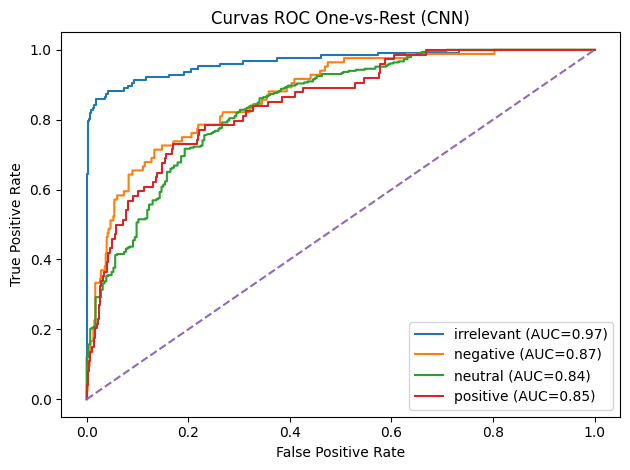

In [121]:
# Binarizar etiquetas reales: (n_samples, n_classes)
y_test_bin = label_binarize(y_test_enc, classes=np.arange(n_classes))

plt.figure()
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC One-vs-Rest (CNN)")
plt.legend()
plt.tight_layout()
plt.show()


Este gráfico muestra las curvas ROC para cada clase. En general, las curvas ROC se sitúan claramente por encima de la línea diagonal, lo que indica que el modelo CNN discrimina correctamente entre las distintas clases y obtiene un rendimiento muy superior al azar. En particular, la clase irrelevant presenta el mejor resultado (AUC = 0.97), seguida de negative (AUC = 0.87), mientras que positive (AUC = 0.84) y neutral (AUC = 0.85) muestran también una capacidad de clasificación muy alta aunque ligeramente inferior.

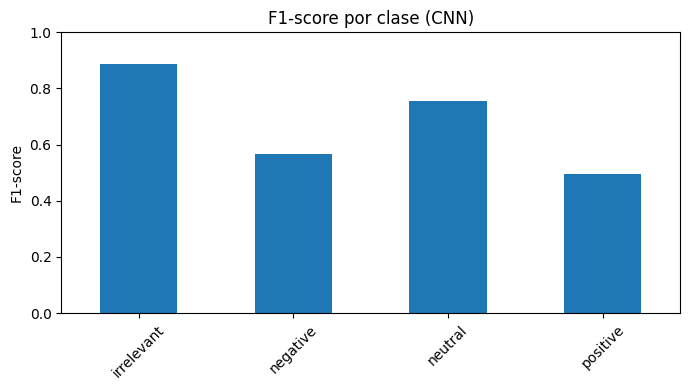

In [122]:
# Report en formato diccionario
report = classification_report(
    y_test_enc,
    y_pred_enc,
    target_names=class_names,
    output_dict=True
)

# Convertir a DataFrame
df_report = pd.DataFrame(report).transpose()

# Extraer solo F1 de cada clase
f1_scores = df_report.loc[class_names, "f1-score"]

# Plot
plt.figure(figsize=(7,4))
f1_scores.plot(kind="bar")

plt.title("F1-score por clase (CNN)")
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


El gráfico muestra que el modelo CNN obtiene un rendimiento desigual según la clase: alcanza valores altos de F1 en los tweets irrelevantes y neutrales, mientras que el desempeño es notablemente menor en los sentimientos negativos y positivos. Esto sugiere dificultades para clasificar correctamente las clases minoritarias o más complejas, aunque en mucho más preciso que con las LSTM.


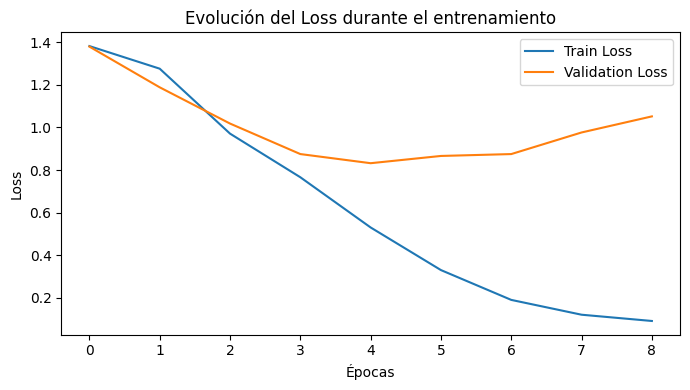

In [123]:
# -------------------------
# Curva de Loss
# -------------------------
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Evolución del Loss durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


Este último gráfico muestra que el *train loss* disminuye de forma continua, indicando que el modelo aprende bien sobre los datos de entrenamiento. Sin embargo, el *validation loss* deja de mejorar a partir de la época 4–5 y comienza a aumentar, lo que sugiere un posible sobreajuste. Esto indica que el modelo empieza a memorizar el entrenamiento en lugar de generalizar correctamente (*overfitting*).


En conjunto, los resultados obtenidos con las redes neuronales muestran un rendimiento condicionado por el desbalance de clases, favoreciendo la categoría mayoritaria y dificultando la identificación de las clases menos representadas. Además, la evolución del *loss* sugiere la aparición de sobreajuste, puesto que el modelo mejora en entrenamiento pero no generaliza de la misma forma en validación. No obstante, las arquitecturas CNN presentan un desempeño ligeramente superior que son las LSTM, logrando capturar mejor ciertos patrones en comparación con otros modelos evaluados.
